# AI Data Quality Pipeline

## Modern Data Engineering for AI Systems

This project implements a data quality pipeline using PySpark to validate order data, detect data quality issues, separate valid and invalid records, and prepare trusted data for analytics.

### Project Objectives

- Validate data quality.
- Detect missing values.
- Detect duplicate records.
- Validate quantities and prices.
- Validate order status values.
- Implement a Quality Gate.
- Store failed records in a Quarantine layer.
- Store clean data using Delta Lake.
- Perform analytics on trusted data.
- Create visualizations to present the results.


## Data Quality Rules

The pipeline applies the following data quality rules:

| Rule ID | Quality Dimension | Rule | Example |
|---|---|---|---|
| DQ-001 | Completeness | `quantity` must not be null | ORD018 |
| DQ-002 | Uniqueness | `order_id` must be unique | ORD002 |
| DQ-003 | Validity | `quantity` must be greater than 0 | ORD016 |
| DQ-004 | Validity | `unit_price` must be greater than 0 | ORD020 |
| DQ-005 | Validity | `status` must be one of the allowed values | ORD019 |

### Allowed Status Values

- Completed
- Pending
- Returned
- Cancelled


# 1. Environment Setup

This section installs and initializes the required tools and libraries for the data quality pipeline.


In [2]:
!pip install pyspark==3.5.3 delta-spark==3.2.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.7 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.3-py2.py3-none-any.whl size=317840691 sha256=3d94fc233818ecfa4aab0bdb2f74928e9748cf502ca59688a123d174904c1bee
  Stored in directory: /root/.cache/pip/wheels/57/01/5d/dd344b64ae939cd8ea67ffa0abd6aed72f14b1165228e281a0
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
  Attempting uninstall: pyspark
    Found existing installation: pyspark 4.0.4
    Uninstalling pyspark-4.0.4:
      Successfully uninstalled pyspark-4.0.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-conn

In [3]:
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip

builder = (
    SparkSession.builder
    .appName("SDAIA_Ecommerce_Pipeline")
    .config(
        "spark.sql.extensions",
        "io.delta.sql.DeltaSparkSessionExtension"
    )
    .config(
        "spark.sql.catalog.spark_catalog",
        "org.apache.spark.sql.delta.catalog.DeltaCatalog"
    )
)

spark = configure_spark_with_delta_pip(builder).getOrCreate()

print("Spark Version:", spark.version)
print("Spark is running successfully!")


Spark Version: 3.5.3
Spark is running successfully!


In [4]:
import os

os.makedirs("/content/data/raw", exist_ok=True)
os.makedirs("/content/data/quarantine", exist_ok=True)
os.makedirs("/content/data/delta", exist_ok=True)

print("Data folders created successfully!")


Data folders created successfully!


# 2. Create and Load Raw Data

This section creates the raw e-commerce order dataset and saves it as a CSV file for the data quality pipeline.


In [5]:
import pandas as pd

data = [
    ["ORD001","CUST001","PROD001","2026-01-01",2,150.00,"Completed","Riyadh","Card"],
    ["ORD002","CUST002","PROD002","2026-01-01",1,250.00,"Completed","Jeddah","Mada"],
    ["ORD003","CUST003","PROD003","2026-01-02",3,75.50,"Completed","Riyadh","Cash"],
    ["ORD004","CUST004","PROD004","2026-01-02",1,450.00,"Pending","Dammam","Card"],
    ["ORD005","CUST005","PROD005","2026-01-03",2,120.00,"Completed","Riyadh","Mada"],
    ["ORD006","CUST006","PROD001","2026-01-03",4,150.00,"Completed","Jeddah","Card"],
    ["ORD007","CUST007","PROD002","2026-01-04",1,250.00,"Returned","Riyadh","Mada"],
    ["ORD008","CUST008","PROD003","2026-01-04",5,75.50,"Completed","Makkah","Cash"],
    ["ORD009","CUST009","PROD004","2026-01-05",2,450.00,"Completed","Riyadh","Card"],
    ["ORD010","CUST010","PROD005","2026-01-05",3,120.00,"Completed","Dammam","Mada"],
    ["ORD011","CUST011","PROD001","2026-01-06",1,150.00,"Completed","Riyadh","Card"],
    ["ORD012","CUST012","PROD002","2026-01-06",2,250.00,"Pending","Jeddah","Mada"],
    ["ORD013","CUST013","PROD003","2026-01-07",4,75.50,"Completed","Riyadh","Cash"],
    ["ORD014","CUST014","PROD004","2026-01-07",1,450.00,"Completed","Madinah","Card"],
    ["ORD015","CUST015","PROD005","2026-01-08",2,120.00,"Completed","Riyadh","Mada"],

    # Invalid records for Data Quality testing
    ["ORD016","CUST016","PROD001","2026-01-08",-2,150.00,"Completed","Jeddah","Card"],
    ["ORD002","CUST017","PROD006","2026-01-09",1,300.00,"Completed","Riyadh","Mada"],
    ["ORD018","CUST018","PROD003","2026-01-09",None,75.50,"Completed","Dammam","Cash"],
    ["ORD019","CUST019","PROD004","2026-01-10",2,450.00,"Unknown","Riyadh","Card"],
    ["ORD020","CUST020","PROD005","2026-01-10",1,-120.00,"Completed","Jeddah","Mada"],
]

columns = [
    "order_id",
    "customer_id",
    "product_id",
    "order_date",
    "quantity",
    "unit_price",
    "status",
    "customer_city",
    "payment_method"
]

orders_pd = pd.DataFrame(data, columns=columns)

orders_pd.to_csv(
    "/content/data/raw/orders.csv",
    index=False
)

print("orders.csv created successfully!")
print("Number of records:", len(orders_pd))


orders.csv created successfully!
Number of records: 20


In [6]:
orders_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("/content/data/raw/orders.csv")
)

print("Data loaded successfully!")
print("Number of records:", orders_df.count())


Data loaded successfully!
Number of records: 20


In [7]:
orders_df.show(20, truncate=False)


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status   |customer_city|payment_method|
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|ORD001  |CUST001    |PROD001   |2026-01-01|2.0     |150.0     |Completed|Riyadh       |Card          |
|ORD002  |CUST002    |PROD002   |2026-01-01|1.0     |250.0     |Completed|Jeddah       |Mada          |
|ORD003  |CUST003    |PROD003   |2026-01-02|3.0     |75.5      |Completed|Riyadh       |Cash          |
|ORD004  |CUST004    |PROD004   |2026-01-02|1.0     |450.0     |Pending  |Dammam       |Card          |
|ORD005  |CUST005    |PROD005   |2026-01-03|2.0     |120.0     |Completed|Riyadh       |Mada          |
|ORD006  |CUST006    |PROD001   |2026-01-03|4.0     |150.0     |Completed|Jeddah       |Card          |
|ORD007  |CUST007    |PROD002   |2026-01-04|1.0     |250.0     |

# 3. Data Quality Validation

This section checks the raw data for missing values, duplicate records, invalid quantities, invalid prices, and invalid order statuses.


In [8]:
from pyspark.sql.functions import col, sum

missing_values = orders_df.select(
    [
        sum(col(c).isNull().cast("int")).alias(c)
        for c in orders_df.columns
    ]
)

missing_values.show()


+--------+-----------+----------+----------+--------+----------+------+-------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status|customer_city|payment_method|
+--------+-----------+----------+----------+--------+----------+------+-------------+--------------+
|       0|          0|         0|         0|       1|         0|     0|            0|             0|
+--------+-----------+----------+----------+--------+----------+------+-------------+--------------+



In [9]:
missing_quantity = orders_df.filter(
    col("quantity").isNull()
)

missing_quantity.show()


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|   status|customer_city|payment_method|
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|  ORD018|    CUST018|   PROD003|2026-01-09|    NULL|      75.5|Completed|       Dammam|          Cash|
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+



In [10]:
from pyspark.sql.functions import count

duplicate_orders = (
    orders_df
    .groupBy("order_id")
    .agg(count("*").alias("count"))
    .filter(col("count") > 1)
)

duplicate_orders.show()


+--------+-----+
|order_id|count|
+--------+-----+
|  ORD002|    2|
+--------+-----+



In [11]:
duplicate_records = orders_df.join(
    duplicate_orders.select("order_id"),
    on="order_id",
    how="inner"
)

duplicate_records.show(truncate=False)


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status   |customer_city|payment_method|
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|ORD002  |CUST002    |PROD002   |2026-01-01|1.0     |250.0     |Completed|Jeddah       |Mada          |
|ORD002  |CUST017    |PROD006   |2026-01-09|1.0     |300.0     |Completed|Riyadh       |Mada          |
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+



In [13]:
invalid_quantity = orders_df.filter(
    col("quantity") <= 0
)

invalid_quantity.show(truncate=False)


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status   |customer_city|payment_method|
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|ORD016  |CUST016    |PROD001   |2026-01-08|-2.0    |150.0     |Completed|Jeddah       |Card          |
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+



In [14]:
invalid_price = orders_df.filter(
    col("unit_price") <= 0
)

invalid_price.show(truncate=False)


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status   |customer_city|payment_method|
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+
|ORD020  |CUST020    |PROD005   |2026-01-10|1.0     |-120.0    |Completed|Jeddah       |Mada          |
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+



In [15]:
valid_statuses = [
    "Completed",
    "Pending",
    "Returned",
    "Cancelled"
]

invalid_status = orders_df.filter(
    ~col("status").isin(valid_statuses)
)

invalid_status.show(truncate=False)


+--------+-----------+----------+----------+--------+----------+-------+-------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status |customer_city|payment_method|
+--------+-----------+----------+----------+--------+----------+-------+-------------+--------------+
|ORD019  |CUST019    |PROD004   |2026-01-10|2.0     |450.0     |Unknown|Riyadh       |Card          |
+--------+-----------+----------+----------+--------+----------+-------+-------------+--------------+



# 4. Quality Gate

This section applies the data quality rules and classifies each record as PASS or FAIL. Failed records are assigned a reason for the quality issue.


In [16]:
from pyspark.sql.functions import (
    col,
    when,
    lit,
    concat_ws
)

valid_statuses = [
    "Completed",
    "Pending",
    "Returned",
    "Cancelled"
]


In [17]:
missing_quantity = col("quantity").isNull()

duplicate_order = col("order_id").isin(
    duplicate_orders.select("order_id").rdd.flatMap(lambda x: x).collect()
)

invalid_quantity = col("quantity") <= 0

invalid_price = col("unit_price") <= 0

invalid_status = ~col("status").isin(valid_statuses)


In [18]:
quality_reason = (
    when(missing_quantity, lit("Missing quantity"))
    .when(duplicate_order, lit("Duplicate order_id"))
    .when(invalid_quantity, lit("Invalid quantity"))
    .when(invalid_price, lit("Invalid unit_price"))
    .when(invalid_status, lit("Invalid status"))
    .otherwise(lit("Valid record"))
)


In [19]:
quality_status = (
    when(
        missing_quantity |
        duplicate_order |
        invalid_quantity |
        invalid_price |
        invalid_status,
        lit("FAIL")
    )
    .otherwise(lit("PASS"))
)


In [20]:
quality_df = (
    orders_df
    .withColumn("quality_status", quality_status)
    .withColumn("quality_reason", quality_reason)
)

quality_df.show(truncate=False)


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+--------------+------------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status   |customer_city|payment_method|quality_status|quality_reason    |
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+--------------+------------------+
|ORD001  |CUST001    |PROD001   |2026-01-01|2.0     |150.0     |Completed|Riyadh       |Card          |PASS          |Valid record      |
|ORD002  |CUST002    |PROD002   |2026-01-01|1.0     |250.0     |Completed|Jeddah       |Mada          |FAIL          |Duplicate order_id|
|ORD003  |CUST003    |PROD003   |2026-01-02|3.0     |75.5      |Completed|Riyadh       |Cash          |PASS          |Valid record      |
|ORD004  |CUST004    |PROD004   |2026-01-02|1.0     |450.0     |Pending  |Dammam       |Card          |PASS          |Valid record      |
|ORD005  |CUST005    |PROD005   |2

# 5. Clean Data and Quarantine

This section separates valid records from failed records after applying the Quality Gate.


In [21]:
clean_df = quality_df.filter(
    col("quality_status") == "PASS"
)

clean_df.show(truncate=False)


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+--------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status   |customer_city|payment_method|quality_status|quality_reason|
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+--------------+--------------+
|ORD001  |CUST001    |PROD001   |2026-01-01|2.0     |150.0     |Completed|Riyadh       |Card          |PASS          |Valid record  |
|ORD003  |CUST003    |PROD003   |2026-01-02|3.0     |75.5      |Completed|Riyadh       |Cash          |PASS          |Valid record  |
|ORD004  |CUST004    |PROD004   |2026-01-02|1.0     |450.0     |Pending  |Dammam       |Card          |PASS          |Valid record  |
|ORD005  |CUST005    |PROD005   |2026-01-03|2.0     |120.0     |Completed|Riyadh       |Mada          |PASS          |Valid record  |
|ORD006  |CUST006    |PROD001   |2026-01-03|4.0     |150.0    

In [22]:
quarantine_df = quality_df.filter(
    col("quality_status") == "FAIL"
)

quarantine_df.show(truncate=False)


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+--------------+------------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status   |customer_city|payment_method|quality_status|quality_reason    |
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+--------------+------------------+
|ORD002  |CUST002    |PROD002   |2026-01-01|1.0     |250.0     |Completed|Jeddah       |Mada          |FAIL          |Duplicate order_id|
|ORD016  |CUST016    |PROD001   |2026-01-08|-2.0    |150.0     |Completed|Jeddah       |Card          |FAIL          |Invalid quantity  |
|ORD002  |CUST017    |PROD006   |2026-01-09|1.0     |300.0     |Completed|Riyadh       |Mada          |FAIL          |Duplicate order_id|
|ORD018  |CUST018    |PROD003   |2026-01-09|NULL    |75.5      |Completed|Dammam       |Cash          |FAIL          |Missing quantity  |
|ORD019  |CUST019    |PROD004   |2

# 6. Quality Summary

This section summarizes the number of total, passed, and failed records after applying the data quality rules.


In [23]:
total_records = quality_df.count()
passed_records = clean_df.count()
failed_records = quarantine_df.count()

print("Total Records :", total_records)
print("Passed Records:", passed_records)
print("Failed Records:", failed_records)


Total Records : 20
Passed Records: 14
Failed Records: 6


In [24]:
quarantine_path = "/content/data/quarantine/orders"

quarantine_df.write \
    .mode("overwrite") \
    .option("header", True) \
    .csv(quarantine_path)

print("Failed records saved to Quarantine.")


Failed records saved to Quarantine.


# 7. Store Clean Data in Delta Lake

This section stores the validated and clean records in Delta Lake format for reliable downstream analytics.


In [26]:
delta_path = "/content/data/delta/orders"

print("Delta table path:", delta_path)


Delta table path: /content/data/delta/orders


In [27]:
clean_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save(delta_path)

print("Clean data saved to Delta Lake successfully!")


Clean data saved to Delta Lake successfully!


In [28]:
delta_df = (
    spark.read
    .format("delta")
    .load(delta_path)
)

print("Data loaded from Delta Lake successfully!")
print("Records in Delta Lake:", delta_df.count())


Data loaded from Delta Lake successfully!
Records in Delta Lake: 14


In [29]:
delta_df.show(truncate=False)


+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+--------------+--------------+
|order_id|customer_id|product_id|order_date|quantity|unit_price|status   |customer_city|payment_method|quality_status|quality_reason|
+--------+-----------+----------+----------+--------+----------+---------+-------------+--------------+--------------+--------------+
|ORD001  |CUST001    |PROD001   |2026-01-01|2.0     |150.0     |Completed|Riyadh       |Card          |PASS          |Valid record  |
|ORD003  |CUST003    |PROD003   |2026-01-02|3.0     |75.5      |Completed|Riyadh       |Cash          |PASS          |Valid record  |
|ORD004  |CUST004    |PROD004   |2026-01-02|1.0     |450.0     |Pending  |Dammam       |Card          |PASS          |Valid record  |
|ORD005  |CUST005    |PROD005   |2026-01-03|2.0     |120.0     |Completed|Riyadh       |Mada          |PASS          |Valid record  |
|ORD006  |CUST006    |PROD001   |2026-01-03|4.0     |150.0    

# 8. Analytics on Clean Data

This section performs basic analytics on the trusted data stored in Delta Lake.


In [30]:
from pyspark.sql.functions import round

analytics_df = delta_df.withColumn(
    "total_amount",
    round(col("quantity") * col("unit_price"), 2)
)

analytics_df.select(
    "order_id",
    "quantity",
    "unit_price",
    "total_amount"
).show()


+--------+--------+----------+------------+
|order_id|quantity|unit_price|total_amount|
+--------+--------+----------+------------+
|  ORD001|     2.0|     150.0|       300.0|
|  ORD003|     3.0|      75.5|       226.5|
|  ORD004|     1.0|     450.0|       450.0|
|  ORD005|     2.0|     120.0|       240.0|
|  ORD006|     4.0|     150.0|       600.0|
|  ORD007|     1.0|     250.0|       250.0|
|  ORD008|     5.0|      75.5|       377.5|
|  ORD009|     2.0|     450.0|       900.0|
|  ORD010|     3.0|     120.0|       360.0|
|  ORD011|     1.0|     150.0|       150.0|
|  ORD012|     2.0|     250.0|       500.0|
|  ORD013|     4.0|      75.5|       302.0|
|  ORD014|     1.0|     450.0|       450.0|
|  ORD015|     2.0|     120.0|       240.0|
+--------+--------+----------+------------+



In [40]:
import builtins

total_sales = analytics_df.agg(
    {"total_amount": "sum"}
).collect()[0][0]

print("Total Sales:", builtins.round(total_sales, 2), "SAR")


Total Sales: 5346.0 SAR


In [33]:
total_orders = analytics_df.select("order_id").distinct().count()

print("Total Valid Orders:", total_orders)


Total Valid Orders: 14


In [41]:
from pyspark.sql.functions import avg

average_order_value = analytics_df.agg(
    avg("total_amount")
).collect()[0][0]

print(
    "Average Order Value:",
    builtins.round(average_order_value, 2),
    "SAR"
)


Average Order Value: 381.86 SAR


In [35]:
city_sales = (
    analytics_df
    .groupBy("customer_city")
    .agg(
        {"total_amount": "sum"}
    )
    .withColumnRenamed("sum(total_amount)", "total_sales")
    .orderBy("total_sales", ascending=False)
)

city_sales.show()


+-------------+-----------+
|customer_city|total_sales|
+-------------+-----------+
|       Riyadh|     2608.5|
|       Jeddah|     1100.0|
|       Dammam|      810.0|
|      Madinah|      450.0|
|       Makkah|      377.5|
+-------------+-----------+



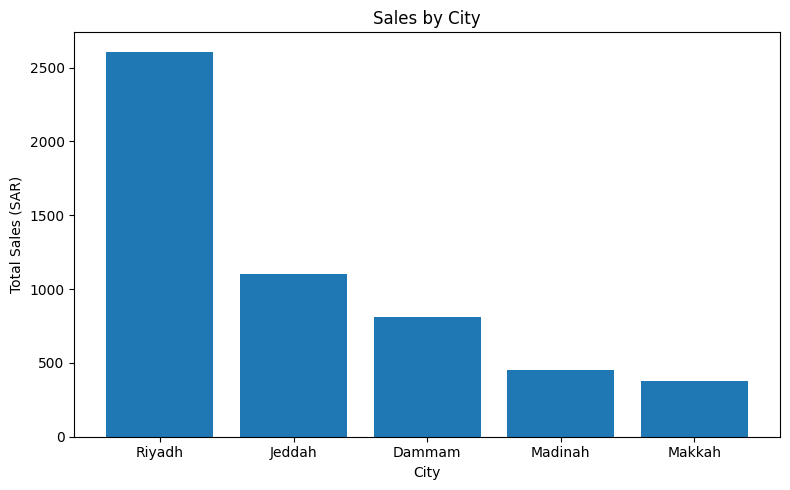

In [42]:
city_sales_pd = city_sales.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    city_sales_pd["customer_city"],
    city_sales_pd["total_sales"]
)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales (SAR)")

plt.tight_layout()
plt.show()


In [36]:
product_sales = (
    analytics_df
    .groupBy("product_id")
    .agg(
        {"total_amount": "sum"}
    )
    .withColumnRenamed("sum(total_amount)", "total_sales")
    .orderBy("total_sales", ascending=False)
)

product_sales.show()


+----------+-----------+
|product_id|total_sales|
+----------+-----------+
|   PROD004|     1800.0|
|   PROD001|     1050.0|
|   PROD003|      906.0|
|   PROD005|      840.0|
|   PROD002|      750.0|
+----------+-----------+



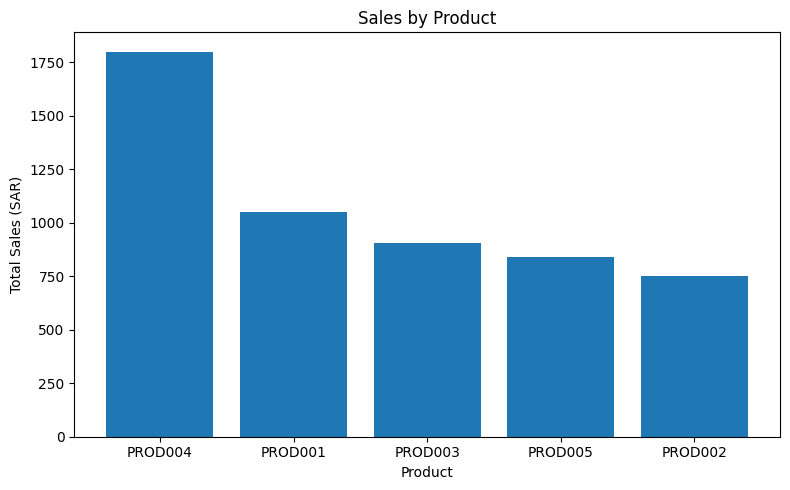

In [43]:
import matplotlib.pyplot as plt

product_sales_pd = product_sales.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    product_sales_pd["product_id"],
    product_sales_pd["total_sales"]
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales (SAR)")

plt.tight_layout()
plt.show()
